# PSO aplicado à Análise Multicritério de Inundação

Este notebook aplica o algoritmo Particle Swarm Optimization (PSO) para otimizar os pesos de uma análise multicritério com base em manchas de inundação.  
O objetivo é calibrar automaticamente os pesos dos critérios,melhorandoo a precisão em relação às áreas de inundação observadas.


## Importação das bibliotecas

In [1]:
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform
from rasterio.transform import from_origin
from rasterio.mask import mask
from rasterio.windows import from_bounds
from rasterio.plot import show, reshape_as_image
from branca.element import Template, MacroElement
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from folium.plugins import Draw, MousePosition
import geopandas as gpd
import numpy as np
import rasterio
import folium

## Funções auxiliares

In [45]:
def carregar_raster(path):
    """
    Método para ler um arquivo raster

    Args:
        path (str): caminho do arquivo
        
    Returns:
        array

    """
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan   # substitui valores ausentes (No Data) por NaN
    return arr


def normalizar_raster(input_path, output_path, novo_min=0, novo_max=4):
    """
    Normaliza um raster para um intervalo definido e salva o novo arquivo.

    Args:
        input_path (str): caminho do arquivo raster
        output_path (str): caminho onde o arquivo normalizado será salvo
        novo_min (int): limite mínimo
        novo_max (int): limite máximo
    """
    with rasterio.open(input_path) as src:
        arr = src.read(1).astype(float)
        profile = src.profile
        nodata = src.nodata
        
        if nodata is not None:
            arr[arr == nodata] = np.nan
        
        old_min = np.nanmin(arr)
        old_max = np.nanmax(arr)
        
        # Normalização Min-Max → novo_min a novo_max
        # fórmula: (x - old_min) / (old_max - old_min) * (novo_max - novo_min) + novo_min
        norm = (arr - old_min) / (old_max - old_min)
        norm = norm * (novo_max - novo_min) + novo_min
        
        # Recoloca NoData como -9999
        norm = np.where(np.isnan(norm), nodata, norm)
        
        profile.update(dtype=rasterio.float32)

    # Salva o raster normalizado
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(norm.astype(rasterio.float32), 1)

    print(f"Raster normalizado salvo em: {output_path}")


def plot_raster(raster_path, titulo, colors="RdYlGn_r"):
    """
    Método para visualiza um raster.

    Args:
        raster_path (str): caminho do arquivo raster
        titulo (str): título da imagem
        colors (str): escala de cores a ser utilizada
    """
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
            
        raster = np.ma.masked_invalid(arr)

    plt.figure(figsize=(8, 6))
    plt.title(titulo)
    
    img = plt.imshow(raster, cmap=colors, vmin=0, vmax=4)
    
    plt.colorbar(img, label="Índice de Risco")
    plt.axis("off")
    plt.show()


def recortar_mapa(raster_path, output_path):
    """
    Método para recortar um raster usando os limites do município de Recife.

    Args:
        raster_path (str): caminho do arquivo raster
        output_path (str): caminho onde o raster recortado será salvo
    """
    limite_path = f"dados/limite_recife_reprojetado.shp"
    
    gdf = gpd.read_file(limite_path)
    geometries = gdf.geometry.values

    with rasterio.open(raster_path) as src:
        dtype = src.dtypes[0]

        # Escolher valor de NoData dependendo do tipo do raster
        if np.issubdtype(dtype, np.integer):
            nodata = 0
        else:
            nodata = np.nan

        # Aplicar máscara e recorte
        out_image, out_transform = mask(
            src, geometries, crop=True, filled=True, nodata=nodata
        )

        if np.issubdtype(dtype, np.floating):
            out_image = out_image.astype("float32")

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "dtype": out_image.dtype,
            "nodata": nodata
        })

    with rasterio.open(output_path, "w", **out_meta) as dst:
        dst.write(out_image)

    print(f"Raster recortado salvo em: {output_path}")


def comparar_mapas(raster_paths, titulos, colors="RdYlGn_r", vmax=4):
    """
    Método para comparar rasters plotando lado a lado.

    Args:
        raster_paths (array): caminhos do arquivos rasters
        titulos (array): titulos das imagens
        colors (str): escala de cores a ser usada
        vmax (int): valor máximo na escala gráfica
    """
    n = len(raster_paths)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    
    if n == 1:
        axes = [axes]
    
    for ax, path, titulo in zip(axes, raster_paths, titulos):
        with rasterio.open(path) as src:
            raster = np.ma.masked_invalid(src.read(1))
        
        img = ax.imshow(raster, cmap=colors, vmin=0, vmax=vmax)
        ax.set_title(titulo, fontsize=12)
        ax.axis("off")
    
    cbar = fig.colorbar(img, ax=axes, orientation="vertical", fraction=0.03, pad=0.04)
    cbar.set_label("Índice de Risco", rotation=90)
    plt.show()

## Carregamento dos rasters

In [27]:
uso_path = "dados/uso_do_solo.tif"
hips_path = "dados/hipsometria.tif"
decliv_path = "dados/declividade.tif"
risco_path = "dados/mapa_risco.tif"   # Mapa de risco obtido com a análise multicritério (Sem fluxo acumulado)
manchas_inundacao_path = 'dados/raster-mancha-inundacao-recife.tif' # Arquivo obtido com análise do HEC-RAS

uso = carregar_raster(uso_path)
hips = carregar_raster(hips_path)
decliv = carregar_raster(decliv_path)

In [50]:
manchas_inundacao_norm_path = 'dados/manchas-inundacao-normalizado.tif'

# Normalizar o arquivo de manchas de inundação para ficar com a mesma escala numérica do mapa de risco
normalizar_raster(manchas_inundacao_path, manchas_inundacao_norm_path)

Raster normalizado salvo em: dados/manchas-inundacao-normalizado.tif


In [29]:
manchas_norm = carregar_raster(raster_normalizado_path)

## Visualizar informações sobre os rasters

Para realizar a análise é importante que todos os arquivos possuam a mesma dimensão e sistema de coordenadas (EPSG)

In [31]:
rasters = {
    "Uso do Solo": uso_path,
    "Hipsometria": hips_path,
    "Declividade": decliv_path,
    "Risco de Alagamento": risco_path,
    "Manchas inundação": manchas_inundacao_path,
    "Manchas Inundação (Normalizado)": manchas_inundacao_norm_path,
}

for nome, path in rasters.items():
    with rasterio.open(path) as src:
        print(f"{nome}:")
        print(f"Dimensões (linhas, colunas): {src.height}, {src.width}")
        print(f"Bounds (extensão): {src.bounds}")
        print(f"Resolução (pixel size): {src.res}")
        print(f"  Número de bandas: {src.count}")
        print(f"  CRS: {src.crs}")
        print(f"  Transform: {src.transform}")
        print(f"NoData value: {src.nodata}")
        
        dados = src.read(1)
        # Mostrar algumas estatísticas
        print("Shape:", dados.shape)
        print("Min:", np.nanmin(dados))
        print("Max:", np.nanmax(dados))
        print("Mean:", np.nanmean(dados))
        print()


Uso do Solo:
Dimensões (linhas, colunas): 898, 646
Bounds (extensão): BoundingBox(left=276747.7872667955, bottom=9097058.175284462, right=296127.7872667955, top=9123998.175284462)
Resolução (pixel size): (30.0, 30.0)
  Número de bandas: 1
  CRS: EPSG:31985
  Transform: | 30.00, 0.00, 276747.79|
| 0.00,-30.00, 9123998.18|
| 0.00, 0.00, 1.00|
NoData value: 0.0
Shape: (898, 646)
Min: 0
Max: 4
Mean: 2.037684362222207

Hipsometria:
Dimensões (linhas, colunas): 898, 646
Bounds (extensão): BoundingBox(left=276747.7872667955, bottom=9097058.175284462, right=296127.7872667955, top=9123998.175284462)
Resolução (pixel size): (30.0, 30.0)
  Número de bandas: 1
  CRS: EPSG:31985
  Transform: | 30.00, 0.00, 276747.79|
| 0.00,-30.00, 9123998.18|
| 0.00, 0.00, 1.00|
NoData value: None
Shape: (898, 646)
Min: 0
Max: 4
Mean: 1.4337037241341268

Declividade:
Dimensões (linhas, colunas): 898, 646
Bounds (extensão): BoundingBox(left=276747.7872667955, bottom=9097058.175284462, right=296127.7872667955, top=9

## Algoritmo do PSO

In [37]:
def funcao_objetivo(pesos):
    pesos = np.array(pesos)
    pesos = pesos / np.sum(pesos)

    w1, w2, w3 = pesos

    # gerando o mapa ponderado
    mapa = w1*uso + w2*hips + w3*decliv

    mask_valid = ~np.isnan(manchas_norm)

    # Para o erro foi usada a diferença entre o mapa ponderado e as manchas do hec-ras
    # Para calcular essa diferença foi utilizado o erro quadrático médio
    erro = np.nanmean((mapa[mask_valid] - manchas_norm[mask_valid]) ** 2)

    return erro


class Particle:
    def __init__(self, x0, bounds):
        self.position = np.array(x0)
        self.velocity = np.random.uniform(-1, 1, len(x0))
        self.pos_best = np.copy(self.position)
        self.err_best = float("inf")
        self.err = float("inf")
        self.bounds = bounds

    def evaluate(self, func):
        self.err = func(self.position)
        if self.err < self.err_best:
            self.err_best = self.err
            self.pos_best = np.copy(self.position)

    def update_velocity(self, global_best):
        w = 0.5
        c1 = 1
        c2 = 2

        r1 = np.random.random(len(self.position))
        r2 = np.random.random(len(self.position))

        cognitive = c1 * r1 * (self.pos_best - self.position)
        social = c2 * r2 * (global_best - self.position)

        self.velocity = w*self.velocity + cognitive + social

    def update_position(self):
        self.position = self.position + self.velocity
        for i in range(len(self.position)):
            self.position[i] = np.clip(self.position[i], self.bounds[i][0], self.bounds[i][1])


class PSO:
    def __init__(self, costFuncion, initial, bounds, n_particles=30, max_iter=80):
        num_dim = len(initial)
        swarm = [Particle(initial, bounds) for _ in range(n_particles)]

        global_best_pos = np.copy(initial)
        global_best_err = float("inf")

        for it in range(max_iter):

            for particle in swarm:
                particle.evaluate(costFuncion)

                if particle.err < global_best_err:
                    global_best_err = particle.err
                    global_best_pos = np.copy(particle.position)

            for particle in swarm:
                particle.update_velocity(global_best_pos)
                particle.update_position()

            print(f"Iteração {it+1}/{max_iter} | Erro = {global_best_err:.6f}")

        print("\n=== RESULTADO FINAL ===")
        print("Melhores pesos:", global_best_pos)
        pesos_norm = global_best_pos / np.sum(global_best_pos)    # Normaliza os pesos para a soma deles dar 1
        print("Melhores pesos (normalizados):", pesos_norm)
        print("Erro:", global_best_err)

## Otimização com o PSO

In [38]:
initial = [0.33, 0.33, 0.33]            # valores iniciais dos pesos
bounds = [(0.01, 1), (0.01, 1), (0.01, 1)]       # limites que os pesos podem assumir

PSO(funcao_objetivo, initial, bounds, n_particles=30, max_iter=10)


Iteração 1/10 | Erro = 5.473798
Iteração 2/10 | Erro = 4.276151
Iteração 3/10 | Erro = 4.268266
Iteração 4/10 | Erro = 4.267359
Iteração 5/10 | Erro = 4.267293
Iteração 6/10 | Erro = 4.267293
Iteração 7/10 | Erro = 4.267293
Iteração 8/10 | Erro = 4.267288
Iteração 9/10 | Erro = 4.267288
Iteração 10/10 | Erro = 4.267288

=== RESULTADO FINAL ===
Melhores pesos: [0.47126647 1.         0.01      ]
Melhores pesos (normalizados): [0.31815104 0.67509798 0.00675098]
Erro: 4.2672879406248025


## Criação do mapa de risco com os novos pesos

In [43]:
peso_uso, peso_hipso, peso_declividade = [0.31815104, 0.67509798, 0.00675098]

risco_pso_path = "dados/mapa_risco_pso.tif"

with rasterio.open(uso_path) as src1, \
     rasterio.open(decliv_path) as src2, \
     rasterio.open(hips_path) as src3:

    uso = src1.read(1).astype(float)
    declividade = src2.read(1).astype(float)
    hipso = src3.read(1).astype(float)

    perfil = src1.profile

# Aplicar pesos
risco = (uso * peso_uso) + (declividade * peso_declividade) + (hipso * peso_hipso)

perfil.update(dtype=rasterio.float32, count=1)
with rasterio.open(risco_pso_path, "w", **perfil) as dst:
    dst.write(risco.astype(rasterio.float32), 1)

print("Mapa de risco salvo em:", risco_pso_path)

Mapa de risco salvo em: dados/mapa_risco_pso.tif


## Visualização dos mapas

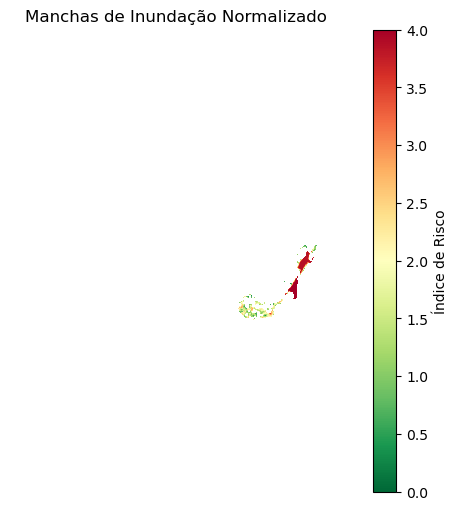

In [41]:
plot_raster(manchas_inundacao_norm_path, 'Manchas de Inundação Normalizado')

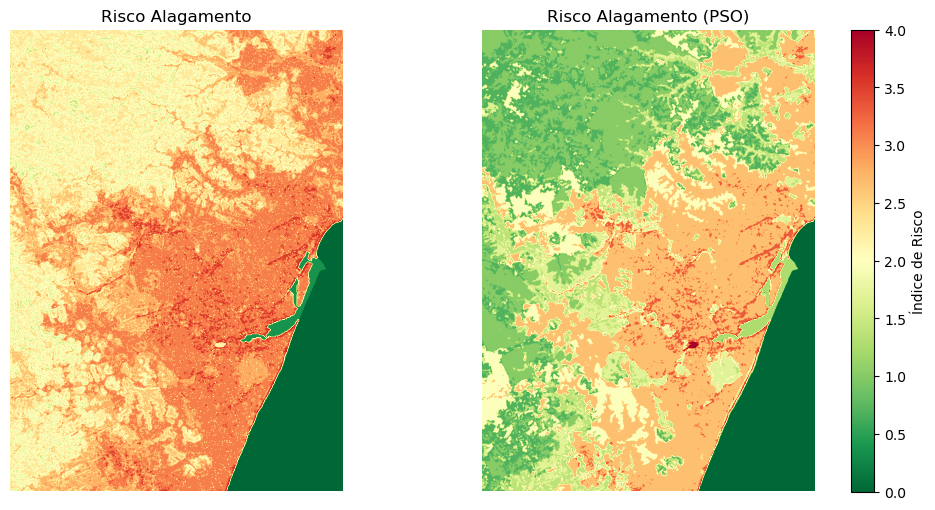

In [46]:
comparar_mapas(
    [risco_path, risco_pso_path],
    ["Risco Alagamento", "Risco Alagamento (PSO)"]
)

In [47]:
risco_recortado_path = 'dados/mapa_risco_recortado.tif'
risco_pso_recortado_path = 'dados/mapa_risco_pso_recortado.tif'

recortar_mapa(risco_path, risco_recortado_path)
recortar_mapa(risco_pso_path, risco_pso_recortado_path)

C:\Users\ezequ\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Raster recortado salvo em: dados/mapa_risco_recortado.tif
Raster recortado salvo em: dados/mapa_risco_pso_recortado.tif


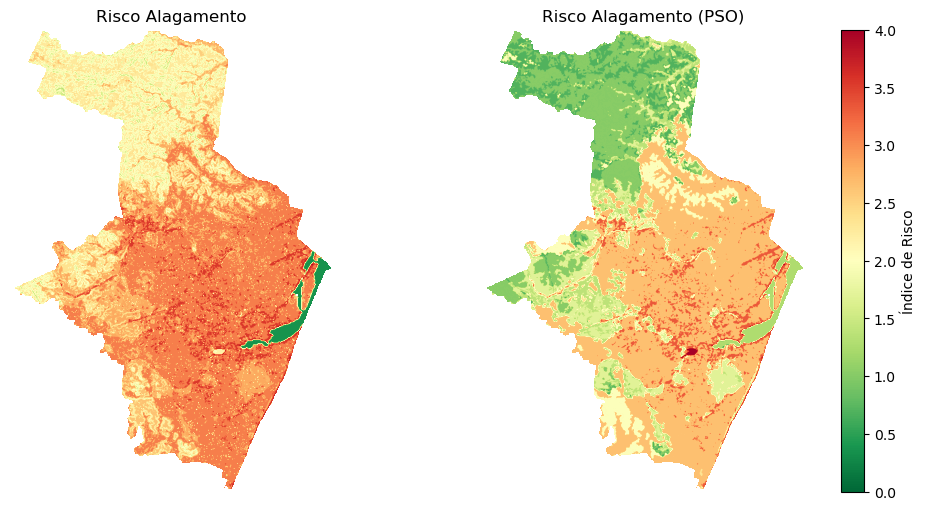

In [48]:
comparar_mapas(
    [risco_recortado_path, risco_pso_recortado_path],
    ["Risco Alagamento", "Risco Alagamento (PSO)"]
)

## Visualização com folium


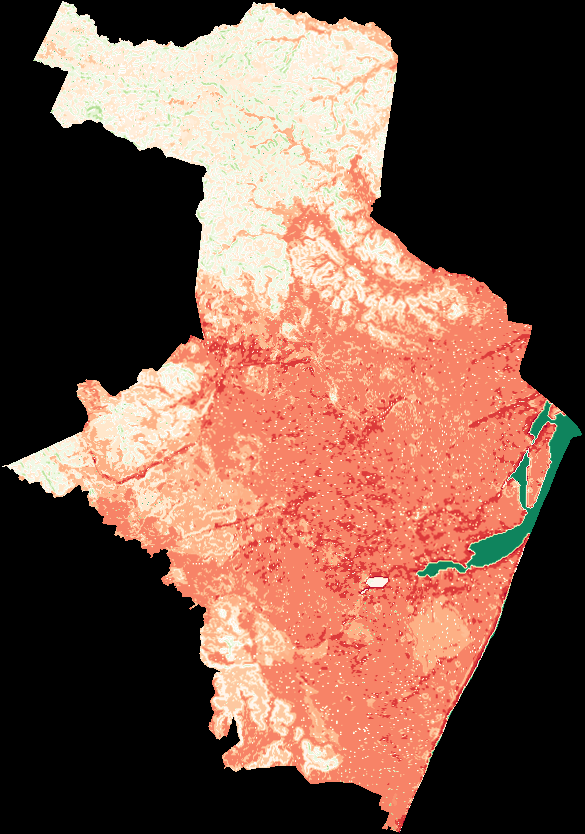
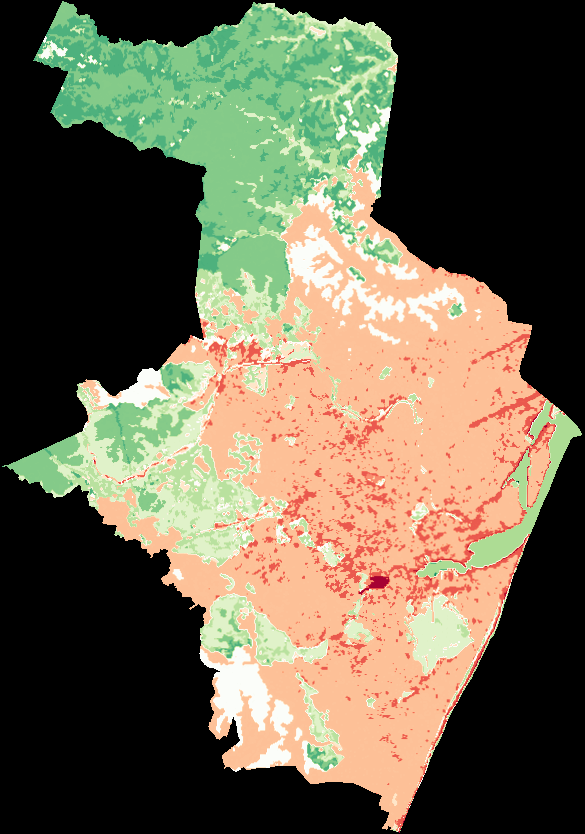
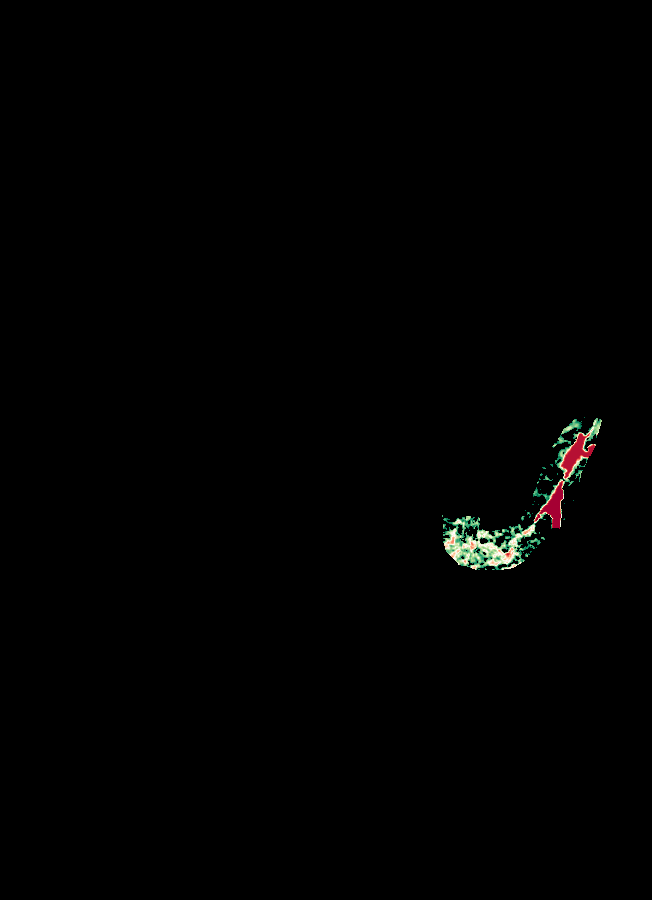

In [49]:
def add_raster_layer(mapa, raster_path, layer_name, colormap=plt.cm.RdYlGn_r):
    with rasterio.open(raster_path) as src:

        nodata = src.nodata if src.nodata is not None else -9999

        # Reprojetando para EPSG:4326
        transform, width, height = calculate_default_transform(
            src.crs, "EPSG:4326", src.width, src.height, *src.bounds
        )

        data_reproj = np.empty((height, width), dtype="float32")

        reproject(
            source=rasterio.band(src, 1),
            destination=data_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:4326",
            resampling=Resampling.bilinear,
            dst_nodata=nodata
        )

        # Substitui nodata por NaN
        data = np.where(data_reproj == nodata, np.nan, data_reproj)

        # Normalização correta (ignorando nan)
        dmin, dmax = np.nanmin(data), np.nanmax(data)
        norm = (data - dmin) / (dmax - dmin)

        # Converte para RGB 0–255
        rgb = (colormap(norm)[:, :, :3] * 255).astype(np.uint8)

        # Bounds geográficos do raster reprojetado
        bounds = rasterio.transform.array_bounds(height, width, transform)
        south, north = min(bounds[1], bounds[3]), max(bounds[1], bounds[3])
        west, east = min(bounds[0], bounds[2]), max(bounds[0], bounds[2])

        # Adiciona ao mapa
        folium.raster_layers.ImageOverlay(
            name=layer_name,
            image=rgb,
            bounds=[[south, west], [north, east]],
            opacity=0.6,
            interactive=True,
            cross_origin=False
        ).add_to(mapa)

mapa = folium.Map(
    location=[-8.07, -34.9],
    zoom_start=11,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Satélite",
    overlay=False,
    control=True
).add_to(mapa)

add_raster_layer(mapa, risco_recortado_path, "Risco de Alagamento")
add_raster_layer(mapa, risco_pso_recortado_path, "Risco de Alagamento (PSO)")
add_raster_layer(mapa, manchas_inundacao_path, "Mancha Inundação")

template = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 20px;
    left: 20px;
    width: 150px;
    height: 160px;
    z-index:9999;
    font-size:14px;
    background-color: white;
    border:2px solid grey;
    border-radius:5px;
    padding: 10px;
    box-shadow: 3px 3px 5px rgba(0,0,0,0.4);
">
    <b>Risco de Alagamento</b><br>
    <i style="background:#d73027;width:20px;height:20px;display:inline-block;margin-right:5px;"></i> Alto<br>
    <i style="background:#ffffb2;width:20px;height:20px;display:inline-block;margin-right:5px;"></i> Moderado<br>
    <i style="background:#78c679;width:20px;height:20px;display:inline-block;margin-right:5px;"></i> Baixo<br>
    <i style="background:#006837;width:20px;height:20px;display:inline-block;margin-right:5px;"></i> Muito Baixo<br>
</div>
{% endmacro %}
"""

macro = MacroElement()
macro._template = Template(template)
mapa.add_child(macro)

# Marcadores de pontos de alagamentos
pontos_alagamento = [
    ("Rua Imperial, bairro de São José", -8.07581, -34.89415),
    ("Rua Nicolau Pereira", -8.07804, -34.90558),
    ("Av. Eng. Abdias de Carvalho", -8.06123, -34.92227),
    ("Av. Dois Rios", -8.11289, -34.93864),
    ("Av. Mal Mascarenhas de Moraes", -8.11383, -34.91281),
    ("Av. Recife e Rua João Cabral de Melo Neto", -8.07953, -34.93374),
    ("Av. Abdias de Carvalho e Rua Delmiro Gouveia", -8.06252, -34.93219),
    ("Av. Norte Miguel Arraes, ao lado do SENAI", -8.04713, -34.87757)
]

for endereco, lat, lon in pontos_alagamento:
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(endereco, max_width=300),
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(mapa)

folium.LatLngPopup().add_to(mapa)

Draw(
    draw_options={'polygon': True, 'rectangle': True, 'marker': True},
    edit_options={'edit': True}
).add_to(mapa)

folium.LayerControl().add_to(mapa)

mapa